# Dự đoán giá điện thoại bằng Gradient Boosting

## Mục tiêu

-   Dự đoán giá điện thoại dựa trên các đặc trưng như RAM, bộ nhớ trong, kích thước màn hình, công nghệ màn hình, v.v.

## Dataset

-   Dataset được sử dụng từ bài thi GK, bao gồm các đặc trưng đã được xử lý qua kỹ thuật Target Encoding.

## Feature Engineering

-   Sử dụng kỹ thuật Target Encoding với K-Fold để mã hóa các cột categorical.
-   Không thay đổi kỹ thuật feature engineering so với bài thi GK.


## Lý thuyết Gradient Boosting

### Gradient Boosting là gì?

-   Gradient Boosting là một thuật toán ensemble kết hợp nhiều cây quyết định để cải thiện dự đoán qua từng bước.
-   Tại mỗi bước boosting, mô hình mới học theo **gradient âm của hàm mất mát** để sửa lỗi từ mô hình trước.

### Hàm mục tiêu (Loss Function)

-   Với bài toán hồi quy: **Mean Squared Error (MSE)**.
    -   Công thức: $\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$

### Các siêu tham số quan trọng

-   `n_estimators`: Số lượng cây (số vòng boosting).
-   `learning_rate`: Hệ số giảm tốc của mỗi cây mới (tránh overfitting).
-   `max_depth`: Độ sâu tối đa của mỗi cây con.
-   `subsample`: Tỷ lệ mẫu được chọn mỗi vòng (giúp tránh overfitting).
-   `min_samples_split`: Số lượng mẫu tối thiểu để chia một nút.
-   `min_samples_leaf`: Số lượng mẫu tối thiểu trong một nút lá.


### Tại sao chọn Mean Squared Error (MSE) làm hàm mất mát?

-   **MSE** là hàm mất mát phổ biến trong các bài toán hồi quy vì:
    -   Nó nhấn mạnh các sai số lớn hơn (do bình phương), giúp mô hình tập trung vào việc giảm các sai số lớn.
    -   Dễ tính toán và có ý nghĩa trực quan (đơn vị giống với đầu ra).
-   Các lựa chọn khác:
    -   **Mean Absolute Error (MAE)**: Ít nhạy cảm với outliers hơn MSE, nhưng không nhấn mạnh các sai số lớn.
    -   **Huber Loss**: Kết hợp ưu điểm của MSE và MAE, phù hợp khi dữ liệu có outliers.
-   Trong bài toán này, MSE được chọn vì chúng tôi muốn mô hình tập trung vào việc giảm các sai số lớn, đặc biệt ở các sản phẩm giá cao.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, train_test_split, RandomizedSearchCV
import json
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt

# Bước 1: Đọc dữ liệu
train_file = '../../data/datasets/train_stratified_by_chip_model.csv'
test_file = '../../data/datasets/test_stratified_by_chip_model.csv'

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

# Các cột cần encoding và cột mục tiêu
categorical_cols = ['chip_model', 'brand', 'screen_tech', 'screen_resolution_k']
target_col = 'price'

# Hiển thị phân phối dữ liệu
print("Phân phối dữ liệu tập train:")
print(train_df['price'].describe())

print("Phân phối dữ liệu tập test:")
print(test_df['price'].describe())

Phân phối dữ liệu tập train:
count    9.630000e+02
mean     9.719232e+06
std      7.761959e+06
min      7.500000e+05
25%      4.440000e+06
50%      7.090000e+06
75%      1.245000e+07
max      5.125000e+07
Name: price, dtype: float64
Phân phối dữ liệu tập test:
count    2.260000e+02
mean     1.061462e+07
std      8.494313e+06
min      1.750000e+06
25%      4.250000e+06
50%      7.970000e+06
75%      1.438500e+07
max      4.179000e+07
Name: price, dtype: float64


In [2]:
# Bước 2: Target Encoding
def target_encode_kfold(df, column, target, n_fold=5, alpha=10):
    df_copy = df.copy()
    global_mean = df_copy[target].mean()
    encoded = pd.Series(index=df_copy.index)
    kf = KFold(n_splits=n_fold, shuffle=True, random_state=42)

    for train_idx, test_idx in kf.split(df_copy):
        means = df_copy.iloc[train_idx].groupby(column)[target].agg(['mean', 'count'])
        smoothed_means = ((means['mean'] * means['count']) + (global_mean * alpha)) / (means['count'] + alpha)
        encoded.iloc[test_idx] = df_copy.iloc[test_idx][column].map(smoothed_means)

    encoded.fillna(global_mean, inplace=True)
    return encoded

# Áp dụng Target Encoding
encoding_means = {}
for col in categorical_cols:
    print(f"Encoding {col}...")
    train_df[f'{col}_encoded'] = target_encode_kfold(train_df, column=col, target=target_col)
    encoding_means[col] = train_df.groupby(col)[f'{col}_encoded'].mean().to_dict()

# Áp dụng encoding cho tập test
for col in categorical_cols:
    test_df[f'{col}_encoded'] = test_df[col].map(encoding_means[col]).fillna(train_df[target_col].mean())

Encoding chip_model...
Encoding brand...
Encoding screen_tech...
Encoding screen_resolution_k...


### Tinh chỉnh siêu tham số

-   **Mục tiêu**: Tìm tổ hợp siêu tham số tối ưu để đạt hiệu suất tốt nhất trên tập kiểm thử.
-   **Các siêu tham số quan trọng**:
    -   `n_estimators`: Số lượng cây. Giá trị lớn hơn có thể cải thiện hiệu suất nhưng dễ gây overfitting.
    -   `learning_rate`: Tốc độ học. Giá trị nhỏ hơn giúp mô hình tổng quát tốt hơn nhưng cần nhiều cây hơn.
    -   `max_depth`: Độ sâu tối đa của cây. Giá trị lớn hơn giúp mô hình học được các mối quan hệ phức tạp nhưng dễ overfit.
    -   `subsample`: Tỷ lệ mẫu được sử dụng cho mỗi cây. Giá trị nhỏ hơn giúp giảm overfitting.
-   **Phương pháp tinh chỉnh**:
    -   Sử dụng **RandomizedSearchCV** để thử nghiệm nhiều tổ hợp siêu tham số trong thời gian ngắn.
    -   Đánh giá hiệu suất bằng **cross-validation** để đảm bảo mô hình tổng quát tốt.


In [3]:
# Bước 3: Chuẩn bị dữ liệu
features = ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 
            'camera_main_resolution', 'camera_count', 'chip_model_encoded', 
            'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']
X_train = train_df[features]
y_train = train_df[target_col]
X_test = test_df[features]
y_test = test_df[target_col]

# Bước 4: Tối ưu hóa siêu tham số
param_dist = {
    'n_estimators': [100, 300, 500, 600, 800],
    'learning_rate': [0.01, 0.005, 0.001],
    'max_depth': [3, 5, 6, 8],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

gb_base = GradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    gb_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    verbose=2,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
    random_state=42
)

print("Tuning hyperparameters...")
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

print("✅ Best Hyperparameters:")
print(random_search.best_params_)

Tuning hyperparameters...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
✅ Best Hyperparameters:
{'subsample': 0.6, 'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 8, 'learning_rate': 0.01}


In [4]:
# Bước 5: Đánh giá mô hình
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")

Mean Absolute Error (MAE): 2224047.219967426
Root Mean Squared Error (RMSE): 3343939.2252741167
R² Score: 0.8443367450467516


Saving best model...
✅ Saved best model to 'best_gb_model.pkl'


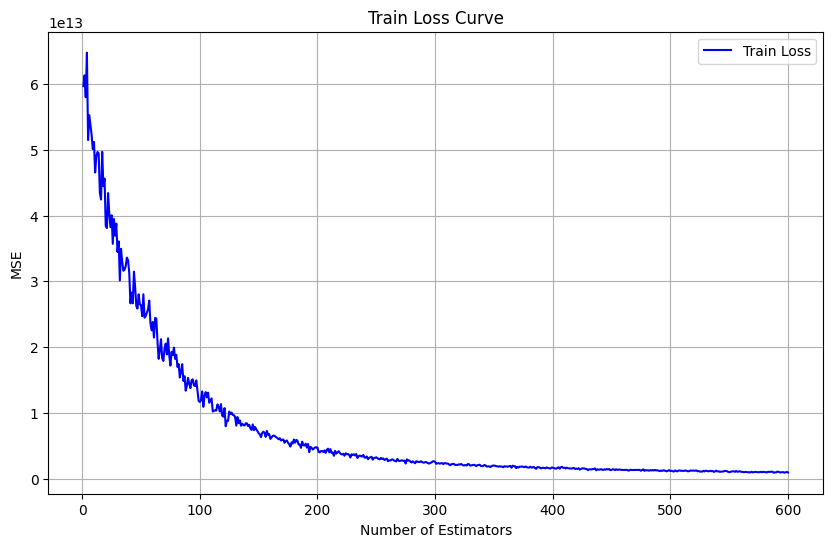

In [5]:
# Lưu model tốt nhất
print("Saving best model...")
joblib.dump(best_model, 'best_gb_model.pkl')
print("✅ Saved best model to 'best_gb_model.pkl'")

# Bước 7: Trực quan hóa loss trên tập train
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(best_model.train_score_) + 1), best_model.train_score_, label='Train Loss', color='blue')
plt.xlabel('Number of Estimators')
plt.ylabel('MSE')
plt.title('Train Loss Curve')
plt.legend()
plt.grid()
plt.show()

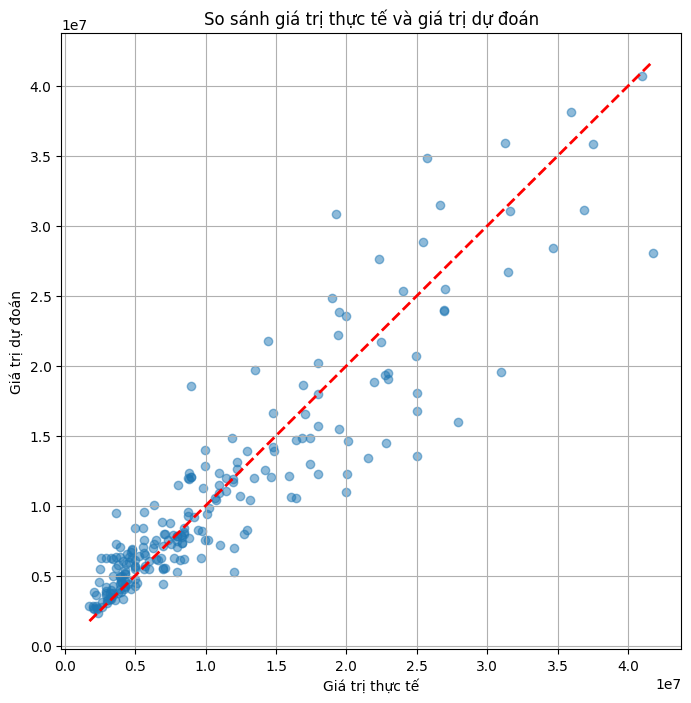

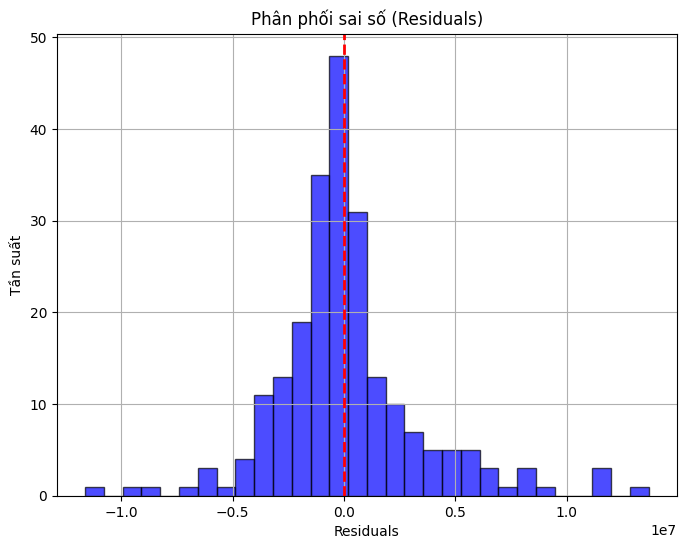

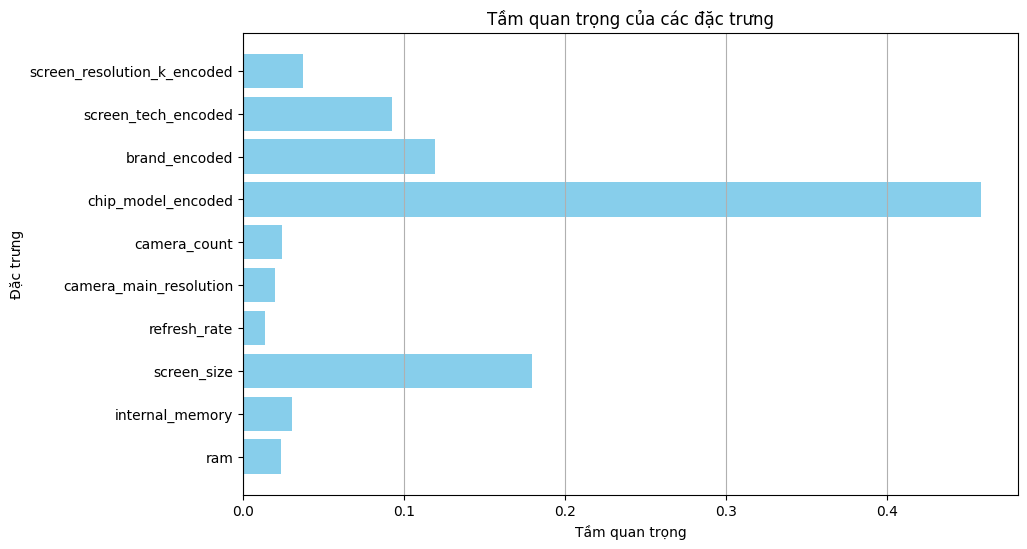

In [6]:
# Biểu đồ scatter giữa giá trị thực tế và giá trị dự đoán
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá trị thực tế')
plt.ylabel('Giá trị dự đoán')
plt.title('So sánh giá trị thực tế và giá trị dự đoán')
plt.grid()
plt.show()

# Biểu đồ phân phối sai số (Residual Plot)
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals')
plt.ylabel('Tần suất')
plt.title('Phân phối sai số (Residuals)')
plt.grid()
plt.show()

# Biểu đồ tầm quan trọng của đặc trưng
feature_importances = best_model.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(features, feature_importances, color='skyblue')
plt.xlabel('Tầm quan trọng')
plt.ylabel('Đặc trưng')
plt.title('Tầm quan trọng của các đặc trưng')
plt.grid(axis='x')
plt.show()

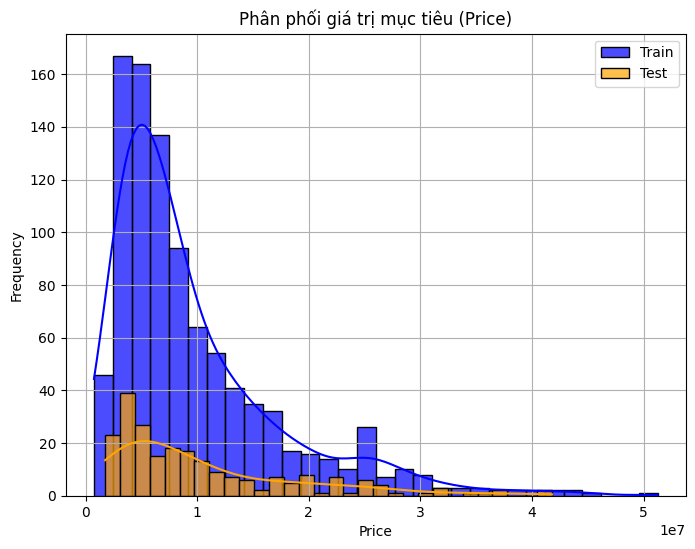

In [7]:
import seaborn as sns

# Phân phối giá trị mục tiêu với seaborn
plt.figure(figsize=(8, 6))
sns.histplot(train_df['price'], bins=30, kde=True, color='blue', label='Train', alpha=0.7, edgecolor='black')
sns.histplot(test_df['price'], bins=30, kde=True, color='orange', label='Test', alpha=0.7, edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Phân phối giá trị mục tiêu (Price)')
plt.legend()
plt.grid()
plt.show()

In [8]:
from sklearn.model_selection import cross_val_score

kfold_scores = -cross_val_score(best_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
print("MAE theo K-Fold (train set):", kfold_scores)
print("Trung bình MAE:", kfold_scores.mean())


MAE theo K-Fold (train set): [1996772.54926879 2389435.44904821 2421310.41681204 2534517.95592129
 2305902.26232692]
Trung bình MAE: 2329587.726675451


## Kết luận

-   Mô hình Gradient Boosting đạt R² = 0.844, cho thấy khả năng dự đoán khá tốt.
-   Tuy nhiên, MAE và RMSE vẫn còn cao, cần cải thiện bằng cách xử lý outliers hoặc thêm đặc trưng mới.
-   Trong tương lai, có thể thử nghiệm thêm các mô hình như XGBoost hoặc LightGBM để so sánh hiệu suất.
